<a href="https://colab.research.google.com/github/RacheliRap/ASRT_analysis/blob/main/HiC/HiC_analysis_cleaned.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hi-C Contact Enrichment Analysis

**Author**: Rachel Rapoport | **Contact**: rachel.rapoport@mail.huji.ac.il

## Workflow Overview

1. **Installation** - Install HiC tools and dependencies
2. **Configuration** - Set analysis parameters  
3. **File Conversion** - Convert .hic → .cool → .h5 format
4. **Data Preparation** - Load matrices and define helper functions
5. **Contact Enrichment** - Calculate within/between group contacts
6. **Permutation Testing** - Statistical significance testing
7. **Visualization** - Create volcano plots

## Configuration

In [ ]:
################################################################################
# CONFIGURATION - Modify these for your analysis
################################################################################

# Data directory
DATA_DIR = "/content/drive/MyDrive/HiC_screening"

# Input files
HIC_FILES = ["ENCFF409ZRS.hic"]  # List of .hic files

# Genome and resolution
GENOME_VERSION = "mm10"
RESOLUTION = 50000  # 50kb bins
CHROMOSOMES = [f"chr{i}" for i in range(1, 23)]

# Transformation (optional)
IS_TRANSFORM = False
TRANSFORMATION = "obs_exp"

# Statistical testing
N_PERMUTATIONS = 1000
BATCH_SIZE = 15
N_JOBS = 2  # Colab CPUs

# Plotting
P_THRESHOLD = 0.05

# Installations

In [ ]:
%%capture
# Install numpy first
!pip install numpy

# Then install scikit-learn
!pip install scikit-learn

# Install other dependencies, letting pip handle their versions of numpy/scipy/joblib
!pip install cooler cooltools hicmatrix hicmatrix.utilities mysql-connector-python  hicexplorer ucsc-bigwigtobedgraph hictk
!apt-get -y install mysql-server bedtool
!service mysql start

In [ ]:
%%capture
! pip install hicmatrix
! pip install hicmatrix.utilities
! sudo apt install bedtools

In [ ]:
%%capture
! pip install cooler
! pip install cooltools

In [ ]:
%%capture
!pip install -q condacolab
import condacolab
condacolab.install()

In [ ]:
import sys
!{sys.executable} -m pip install pysam --upgrade --no-cache-dir


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.0/24.0 MB 62.5 MB/s eta 0:00:00


In [ ]:
import tables
from scipy.sparse import csr_matrix
import pandas as pd
from hicmatrix.utilities import toString
import numpy as np
import h5py
import hicmatrix.HiCMatrix as hm
import random
import cooler
import cooltools
import pysam

In [ ]:
import gc
gc.collect()

0

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


# Format Conversion


In [ ]:
!wget https://www.encodeproject.org/files/ENCFF409ZRS/@@download/ENCFF409ZRS.hic  -O /content/drive/MyDrive/ENCFF409ZRS.hic

In [ ]:
import os
import subprocess

# Define the directory containing the .hic files
data_dir = "/content/drive/MyDrive/HiC_screening"
files =["ENCFF409ZRS.hic"]

# List of chromosomes to iterate over - start with chr format
chromosomes = [f"chr{i}" for i in range(1, 23)]
version = "mm10"
resolution = 50000
is_transform = False
transformation = "obs_exp"
#transformation_list = ["obs_exp", "obs_exp_lieberman", "obs_exp_non_zero"]
transformation_list = ["obs_exp"]

for transformation in transformation_list:
    print(transformation)
    # Input and output paths
    for filename in files:
      print(filename)
      accession = os.path.splitext(os.path.basename(filename))[0]
      print(accession)

      filename = data_dir + "/" + filename
      cool_file = os.path.join(data_dir, f"{accession}_{resolution//1000}kb.cool")

      # Convert .hic to .cool
      subprocess.run([
          "/usr/local/envs/hictk/bin/hictk", "convert",
          filename, cool_file,
          "--resolutions", str(resolution), "--force", "--normalization-methods", "NONE"
      ], check=True)

      #Balance the .cool file
      subprocess.run(["cooler", "balance", cool_file, "--force"], check=True)

      if is_transform:
        # Transform the data to obs/exp
        cool_file_transform = f"{data_dir}/{accession}_{resolution//1000}kb.{transformation}.cool"

        command = ["hicTransform",
                    "--matrix", cool_file,
                    "--outFileName", cool_file_transform,
                    "--method", transformation,
                    "--perChromosome"
                    ]


        print(f"Testing hicTransform...")
        subprocess.run(command, check=True)
        print(f"Successfully processed hicTransform.")

        cool_file = cool_file_transform


      # Test first chromosome to determine format
      test_chromosome = chromosomes[0]  # Try "chr1" first
      h5_file = f"{data_dir}/{accession}_{test_chromosome}_{resolution//1000}kb.h5"
      if is_transform:
            h5_file = f"{data_dir}/{accession}_{test_chromosome}_{resolution//1000}kb.{transformation}.h5"

      command = [
          "hicConvertFormat",
          "--matrices", cool_file,
          "--outFileName", h5_file,
          "--inputFormat", "cool",
          "--outputFormat", "h5",
          "--resolutions", str(resolution),
          "--chromosome", test_chromosome
      ]

      try:
          print(f"Testing chromosome format with {test_chromosome}...")
          subprocess.run(command, check=True)
          print(f"Successfully processed {test_chromosome}. Using chr format.")
          # If successful, continue with chr format

      except subprocess.CalledProcessError as e:
          print(f"chr format failed, trying numeric format...")
          # Switch to numeric format
          chromosomes = [str(i) for i in range(1, 23)]
          test_chromosome = chromosomes[0]  # Now "1"
          h5_file = f"{data_dir}/{accession}_{test_chromosome}_{resolution//1000}kb.h5"
          if is_transform:
              h5_file = f"{data_dir}/{accession}_{test_chromosome}_{resolution//1000}kb.{transformation}.h5"


          command = [
              "hicConvertFormat",
              "--matrices", cool_file,
              "--outFileName", h5_file,
              "--inputFormat", "cool",
              "--outputFormat", "h5",
              "--resolutions", str(resolution),
              "--chromosome", test_chromosome
          ]

          try:
              subprocess.run(command, check=True)
              print(f"Successfully processed {test_chromosome}. Using numeric format.")
          except subprocess.CalledProcessError as e2:
              print(f"Both formats failed for {test_chromosome}: {e2}")
              continue

      # Now process the remaining chromosomes (skip index 0 since we already processed it)
      for chromosome in chromosomes[1:]:
          h5_file = f"{data_dir}/{accession}_{chromosome}_{resolution//1000}kb.h5"

          if is_transform:
              h5_file = f"{data_dir}/{accession}_{chromosome}_{resolution//1000}kb.{transformation}.h5"

          print(h5_file)
          command = [
              "hicConvertFormat",
              "--matrices", cool_file,
              "--outFileName", h5_file,
              "--inputFormat", "cool",
              "--outputFormat", "h5",
              "--resolutions", str(resolution),
              "--chromosome", chromosome
          ]
          try:
              print(f"Processing {chromosome}...")
              subprocess.run(command, check=True)
              print(f"Successfully processed {chromosome}. Output: {h5_file}")
          except subprocess.CalledProcessError as e:
              print(f"Error processing {chromosome}: {e}")

      if not is_transform:
        break


# Data Preparation

In [ ]:
def read_h5(file_name):
    """ Reads an HDF5 file containing a sparse matrix in CSR format. """

    with tables.open_file(file_name, 'r') as f:
        parts = {}

        try:
            for matrix_part in ('data', 'indices', 'indptr', 'shape'):
                parts[matrix_part] = getattr(f.root.matrix, matrix_part).read()

        except Exception as e:
            return None  # Return None instead of an incomplete matrix

        matrix = csr_matrix((parts['data'], parts['indices'], parts['indptr']), shape=parts['shape'])

        f.close()  # Manually close file

    return matrix

def extract_intervals(file_name):
    """ Extracts intervals from an HDF5 file. """
    with tables.open_file(file_name, 'r') as f:
        intvals = {}
        for interval_part in ('chr_list', 'start_list', 'end_list', 'extra_list'):
            if toString(interval_part) == toString('chr_list'):
                chrom_list = getattr(f.root.intervals, interval_part).read()
                intvals[interval_part] = toString(chrom_list)
            else:
                intvals[interval_part] = getattr(f.root.intervals, interval_part).read()

        cut_intervals = list(zip(intvals['chr_list'], intvals['start_list'], intvals['end_list'], intvals['extra_list']))
        intvals_df = pd.DataFrame(intvals)
        intvals_df.to_csv('HiC_intervals.bed', sep='\t', index=False, header=False)


# Permutations - Log2FC

In [ ]:
#@title Count Interactions – Function Definitions

def group_consecutive(numbers):
    # Initialize the result list and group counter
    result = []
    group = 0

    # Convert numbers to numerical values if they are strings
    numbers = pd.to_numeric(numbers, errors='coerce')

    # Iterate through the list of numbers
    for i in range(len(numbers)):
        # Assign the current number to the current group
        result.append(group)

        # Check if the next number is not consecutive
        #Handle NaN values, which might arise from non-numeric chromosome names
        if i < len(numbers) - 1 and (pd.isnull(numbers[i + 1]) or pd.isnull(numbers[i]) or numbers[i + 1] != numbers[i] + 1):
            group += 1  # Increment the group counter

    return result

def within_contacts_optimized(indices, chrs, matrix):
    """
    Count all possible interactions (including zeros) between groups
    within a sparse Hi-C matrix for given indices.

    Parameters:
    - indices: List or array of indices representing the positions to analyze.
    - chrs: List or array of chromosome identifiers corresponding to indices.
    - matrix: Sparse matrix (CSR format) representing Hi-C interactions.

    Returns:
    - interactions_counts: Total number of valid interaction pairs (including zeros).
    - interactions_sum: Sum of interaction values (including zeros).
    """
    interactions_counts = 0
    interactions_sum = 0

    # Ensure inputs are numpy arrays for efficient processing
    indices = np.asarray(indices)
    chrs = np.asarray(chrs)

    # Filter numeric chromosome names
    unique_chrs = [chr for chr in set(chrs) if chr.isdigit()]
    #unique_chrs = set(chrs)

    # Group consecutive indices and convert to numpy array
    groups = np.asarray(group_consecutive(indices))

    for chr in unique_chrs:
        # Get indices for the current chromosome
        chr_indices = np.where(chrs == chr)[0]

        # Map local chromosome indices back to global indices
        global_indices = indices[chr_indices]
        local_groups = groups[chr_indices]

        # Compute a boolean mask for non-self interactions and different groups
        n = len(chr_indices)
        group_matrix = local_groups[:, None] != local_groups  # Group comparison matrix
        non_self_mask = ~np.eye(n, dtype=bool)  # Exclude self-interactions

        # Combine masks to determine valid pairs
        valid_mask = non_self_mask & group_matrix

        # Count valid pairs
        interactions_counts += np.sum(valid_mask)

        # Sum interaction values directly using sparse matrix slicing
        valid_rows, valid_cols = np.where(valid_mask)
        global_rows = global_indices[valid_rows]
        global_cols = global_indices[valid_cols]

        interactions_sum += matrix[global_rows, global_cols].sum()

    return interactions_counts, interactions_sum


#within_grp1_counts3, within_grp1_sum3 = within_contacts_optimized(indices_CAST, chrs_CAST, allele1_matrix)

def between_contacts_optimized(indices_grp1, indices_grp2, chrs_grp1, chrs_grp2, matrix):
    """
    Count interactions between two groups within a sparse Hi-C matrix for given indices.

    Parameters:
    - indices_grp1: List or array of indices representing the positions in group 1.
    - indices_grp2: List or array of indices representing the positions in group 2.
    - chrs_grp1: List or array of chromosome identifiers for group 1.
    - chrs_grp2: List or array of chromosome identifiers for group 2.
    - matrix: Sparse matrix (CSR format) representing Hi-C interactions.

    Returns:
    - interactions_sum: Sum of interaction values (including zeros).
    - interactions_counts: Total number of valid interaction pairs (including zeros).
    """
    interactions_counts = 0
    interactions_sum = 0

    # Ensure inputs are numpy arrays for efficient processing
    indices_grp1 = np.asarray(indices_grp1)
    indices_grp2 = np.asarray(indices_grp2)
    chrs_grp1 = np.asarray(chrs_grp1)
    chrs_grp2 = np.asarray(chrs_grp2)

    # Filter numeric chromosome names
    unique_chrs = [chr for chr in set(chrs_grp1) & set(chrs_grp2) if chr.isdigit()]

    for chr in unique_chrs:
        # Get indices for the current chromosome in both groups
        chr_indices_grp1 = np.where(chrs_grp1 == chr)[0]
        chr_indices_grp2 = np.where(chrs_grp2 == chr)[0]

        # Map group indices back to global indices
        global_grp1 = indices_grp1[chr_indices_grp1]
        global_grp2 = indices_grp2[chr_indices_grp2]

        # Cartesian product of indices to create all pairs between the groups
        rows, cols = np.meshgrid(global_grp1, global_grp2, indexing="ij")

        # Count valid pairs (all pairs are valid)
        interactions_counts += rows.size

        # Sum interaction values for all pairs
        valid_pairs = matrix[rows.ravel(), cols.ravel()].A.flatten()
        interactions_sum += np.sum(valid_pairs)

    # Multiply results by 2 as specified in the original function
    return interactions_counts * 2, interactions_sum * 2,
#between_counts1, between_sum1 = between_contacts_optimized(indices_CAST, indices_C57BL, chrs_CAST, chrs_C57BL, allele1_matrix)


In [ ]:
from joblib import Parallel, delayed
from io import StringIO
import numpy as np
import pandas as pd
import subprocess
from tqdm import tqdm
import tables
import glob
import signal
import gc
import threading
import os
from scipy.sparse import csr_matrix


def handler(signum, frame):
    raise TimeoutError("Reading file took too long!")

def generate_random_permutations(df1, n_permutations):
    """
    Generate random permutations for binary strain classification.
    Simple and fast approach suitable for most analyses.
    """
    strain_column = df1[3].values  # 4th column contains strain info
    unique_strains = np.unique(strain_column)

    if len(unique_strains) != 2:
        raise ValueError(f"Expected 2 strains, got {len(unique_strains)}: {unique_strains}")

    # Display strain distribution
    strain_counts = {strain: np.sum(strain_column == strain) for strain in unique_strains}
    print(f"Strain distribution: {strain_counts}")
    print(f"Total regions: {len(strain_column)}")

    # Generate random permutations
    permutations = []
    np.random.seed(42)  # For reproducible results

    print(f"Generating {n_permutations} random permutations...")
    for i in range(n_permutations):
        perm = np.random.permutation(strain_column)
        permutations.append(perm.copy())

    print(f"Generated {len(permutations)} random permutations")
    return permutations

def process_permutation_batch(args):
    """
    Process a batch of permutations - optimized for Google Colab.
    """
    permutation_batch, df1, chromosome_files, matrices_data = args
    batch_results = []

    for perm_idx, permuted_strains in enumerate(permutation_batch):
        try:
            # Create permuted dataframe
            shuffled_df = df1.copy()
            shuffled_df.iloc[:, 3] = permuted_strains
            permuted_values = []

            for file in chromosome_files:
                if file not in matrices_data:
                    continue

                matrix, intervals_df = matrices_data[file]

                # Thread-safe temp file naming
                thread_id = threading.get_ident()
                temp_file = f'/content/HiC_intervals_thread_{thread_id}_perm_{perm_idx}.bed'

                try:
                    intervals_df.to_csv(temp_file, sep='\t', index=False, header=False)
                    bedtools_cmd = f"awk '$1 != \"X\" {{print;}}' | bedtools intersect -a {temp_file} -b stdin -loj"

                    df_permuted = process_bedtools_intersection(bedtools_cmd, shuffled_df)
                    values = calculate_values_per_chromosome(df_permuted, matrix)
                    permuted_values.append(values)

                except Exception as e:
                    print(f"Error processing file {file} in permutation {perm_idx}: {e}")
                finally:
                    if os.path.exists(temp_file):
                        try:
                            os.remove(temp_file)
                        except:
                            pass

            if permuted_values:
                aggregated_permuted = aggregate_values(permuted_values)
                permuted_logFC = calculate_final_logFC(aggregated_permuted)
                batch_results.append(permuted_logFC)

        except Exception as e:
            print(f"Batch worker error on permutation {perm_idx}: {e}")
            continue

    return batch_results

def run_colab_permutation_test(input_dir, df1, accession, n_permutations=1000, batch_size=15):
    """
    Optimized permutation test for Google Colab using simple random permutations.
    """
    print("🚀 Running Colab-optimized permutation test")
    print("📊 Using random permutation strategy (standard approach)")

    chromosome_files = sorted(glob.glob(f"{input_dir}/{accession}*50kb.h5"))
    chromosome_files = [file for file in chromosome_files if "50kb" in file]

    # Load matrices with Colab memory management
    print("📚 Loading matrices...")
    matrices_data = {}

    for file in tqdm(chromosome_files, desc="Loading matrices"):
        signal.signal(signal.SIGALRM, handler)
        signal.alarm(40)

        try:
            matrix = read_h5(file)
            intervals_df = load_intervals_from_h5(file)
            matrices_data[file] = (matrix, intervals_df)
            gc.collect()  # Colab memory management

        except (TimeoutError, Exception) as e:
            print(f"⚠️ Skipping {file}: {e}")
            continue
        finally:
            signal.alarm(0)

    if not matrices_data:
        raise ValueError("❌ No matrices could be loaded")

    print(f"✅ Loaded {len(matrices_data)} chromosome matrices")

    # Calculate observed logFC
    print("🎯 Calculating observed logFC...")
    observed_values = []
    bedtools_cmd = "awk '$1 != \"X\" {print;}' | bedtools intersect -a /content/HiC_intervals.bed -b stdin -loj"

    for file in chromosome_files:
        if file not in matrices_data:
            continue

        matrix, intervals_df = matrices_data[file]
        intervals_df.to_csv('/content/HiC_intervals.bed', sep='\t', index=False, header=False)

        df_observed = process_bedtools_intersection(bedtools_cmd, df1)
        values = calculate_values_per_chromosome(df_observed, matrix)
        observed_values.append(values)

    aggregated_observed = aggregate_values(observed_values)
    observed_logFC = calculate_final_logFC(aggregated_observed)
    print(f"📊 Observed logFC: {observed_logFC}")

    # Generate random permutations
    print("🎲 Generating random permutations...")
    permutation_arrays = generate_random_permutations(df1, n_permutations)

    # Split into batches for parallel processing
    permutation_batches = []
    for i in range(0, len(permutation_arrays), batch_size):
        batch = permutation_arrays[i:i + batch_size]
        permutation_batches.append(batch)

    print(f"Split into {len(permutation_batches)} batches of ~{batch_size} permutations each")

    # Parallel processing with threading (Colab-friendly)
    print("⚡ Running parallel permutation test...")
    batch_args = [(batch, df1, chromosome_files, matrices_data) for batch in permutation_batches]

    batch_results = Parallel(
        n_jobs=2,  # Colab has 2 CPUs
        verbose=1,
        prefer="threads",
        backend="threading"
    )(
        delayed(process_permutation_batch)(args) for args in tqdm(batch_args, desc="Processing batches")
    )

    # Collect results
    null_distributions = []
    for batch_result in batch_results:
        if batch_result:
            null_distributions.extend(batch_result)

    # Cleanup
    print("🧹 Cleaning up memory...")
    for matrix, _ in matrices_data.values():
        del matrix
    del matrices_data
    tables.file._open_files.close_all()
    gc.collect()

    print(f"✅ Completed {len(null_distributions)} permutations")

    # Calculate statistics
    if null_distributions:
        p_value = (np.sum([logFC >= observed_logFC for logFC in null_distributions]) + 1 ) / (len(null_distributions) + 1)
        #p_value = np.mean([logFC >= observed_logFC for logFC in null_distributions])
        ci_lower, ci_upper = np.percentile(null_distributions, [2.5, 97.5])
    else:
        p_value = np.nan
        ci_lower, ci_upper = np.nan, np.nan

    return {
        'observed_logFC': observed_logFC,
        'observed_fold_change': 2 ** observed_logFC,
        'null_distribution': null_distributions,
        'p_value': p_value,
        'ci_95': (ci_lower, ci_upper),
        'n_permutations_used': len(null_distributions)
    }

def estimate_p_value_confidence_interval(p_value, n_permutations):
    """
    Estimate confidence interval for the p-value using binomial standard error.

    The permutation p-value is a binomial proportion, so its standard error is:
    SE = sqrt(p * (1-p) / n)

    95% confidence interval: p ± 1.96 * SE
    """
    if p_value == 0:
        # Handle edge case where no permutations exceed observed
        p_value = 1 / (2 * n_permutations)  # Conservative estimate

    se = np.sqrt(p_value * (1 - p_value) / n_permutations)
    z_critical = 1.96  # 95% confidence interval
    ci_lower = max(0, p_value - z_critical * se)
    ci_upper = min(1, p_value + z_critical * se)

    return ci_lower, ci_upper, se

# Helper functions (assuming these exist in your environment)
def calculate_values_per_chromosome(df, matrix):
    """Calculate intermediate values for a single chromosome."""
    # Extract indices for each group
    indices_CAST = np.where((df[5] != -1) & (df[7] == "CAST"))[0]
    chrs_CAST = df.loc[(df[5] != -1) & (df[7] == "CAST"),0]
    chrs_CAST = chrs_CAST.astype(str)
    indices_C57BL = np.where((df[5] != -1) & (df[7] != "CAST"))[0]
    chrs_C57BL = df.loc[(df[5] != -1) & (df[7] != "CAST"),0]
    chrs_C57BL = chrs_C57BL.astype(str)

    # Calculate total interactions and number of pairs for each group
    total_contacts_within_group1, num_within_pairs_grp1 = within_contacts_optimized(
       indices_CAST, chrs_CAST, matrix)
    total_contacts_within_group2, num_within_pairs_grp2 = within_contacts_optimized(
        indices_C57BL, chrs_C57BL, matrix)
    total_contacts_between_groups, num_between_pairs = between_contacts_optimized(
        indices_CAST, indices_C57BL, chrs_CAST, chrs_C57BL, matrix)

    return {
        'total_contacts_within_group1': total_contacts_within_group1,
        'num_within_pairs_grp1': num_within_pairs_grp1,
        'total_contacts_within_group2': total_contacts_within_group2,
        'num_within_pairs_grp2': num_within_pairs_grp2,
        'total_contacts_between_groups': total_contacts_between_groups,
        'num_between_pairs': num_between_pairs
    }

def aggregate_values(chromosome_values):
    """Aggregate the values across all chromosomes."""
    return {
        key: sum(values[key] for values in chromosome_values)
        for key in chromosome_values[0]
    }

def calculate_final_logFC(aggregated_values):
    """Calculate the final log2 fold change across all chromosomes."""
    eps = np.finfo(float).eps

    avg_within_1 = aggregated_values['num_within_pairs_grp1'] / (aggregated_values['total_contacts_within_group1'] + eps)
    avg_within_2 = aggregated_values['num_within_pairs_grp2'] / (aggregated_values['total_contacts_within_group2'] + eps)
    avg_within = avg_within_1 + avg_within_2

    avg_between = aggregated_values['num_between_pairs'] / (aggregated_values['total_contacts_between_groups'] + eps)
    ratio = avg_within / ((avg_between ) * 2)
    log2_ratio = np.log2(ratio + eps)

    return log2_ratio

def load_intervals_from_h5(file):
    """Load interval data from an H5 file."""
    with tables.open_file(file, 'r') as f:
        intvals = {}
        for interval_part in ('chr_list', 'start_list', 'end_list', 'extra_list'):
            if interval_part == 'chr_list':
                chrom_list = getattr(f.root.intervals, interval_part).read()
                intvals[interval_part] = chrom_list.astype(str)
            else:
                intvals[interval_part] = getattr(f.root.intervals, interval_part).read()

    intvals_df = pd.DataFrame(intvals)
    intvals_df['chr_list'] = intvals_df['chr_list'].str.replace('^chr', '', regex=True)
    return intvals_df

def process_bedtools_intersection(bedtools_cmd, df):
    """Process bedtools intersection to match intervals."""
    initial_bed = StringIO()
    df.to_csv(initial_bed, sep='\t', index=False, header=False)
    initial_bed.seek(0)

    process = subprocess.run(
        bedtools_cmd,
        input=initial_bed.getvalue(),
        text=True,
        shell=True,
        capture_output=True
    )

    return pd.read_csv(StringIO(process.stdout), sep='\t', header=None).drop_duplicates(subset=[1, 2, 3, 4])

# Main execution
if __name__ == "__main__":
    input_dir = "/content/drive/MyDrive/HiC_screening"

    #organism = "human"
    genomic_version = "mm10"
    random_regions = False

    if genomic_version == "mm9":
        df1 = pd.read_csv('/content/drive/MyDrive/async_master_list.noChr.bed', sep='\t', header=None)
    elif genomic_version == "mm10":
        df1 = pd.read_csv('/content/drive/MyDrive/async_master_list.GRCm38.noChr.bed', sep='\t', header=None)
    elif genomic_version == "hg19":
        df1 = pd.read_csv('/content/drive/MyDrive/async_master_list.liftOver_hg19.filter.bed', sep='\t', header=None)

    if random_regions and genomic_version == "mm10":
        df1 = pd.read_csv('/content/drive/MyDrive/async_master_list.GRCm38.noChr.shuffle.bed', sep='\t', header=None)


    accession = "GSM7305473_HiC-LpreB-WT-R1"
    single = True

    print("🔬 Colab Hi-C Contact Enrichment Analysis")
    print("📊 Using simple random permutation approach (standard in genomics)")
    print("\nStrain distribution:")
    print(df1[3].value_counts())

    #if not single:

    # Run the optimized permutation test
    results = run_colab_permutation_test(
        input_dir,
        df1,
        accession,
        n_permutations=1000,  # Adjust as needed (1000 for exploration, 5000+ for publication)
        batch_size=15
    )

    # Calculate p-value confidence interval
    p_ci_lower, p_ci_upper, p_se = estimate_p_value_confidence_interval(
        results['p_value'],
        results['n_permutations_used']
    )

    # Display results
    print(f"\n🎉 Results:")
    print(f"✓ Permutations used: {results['n_permutations_used']}")
    print(f"📊 Observed log2 ratio: {results['observed_logFC']:.3f}")
    print(f"📈 Observed fold change: {results['observed_fold_change']:.2f}x")
    print(f"🎯 P-value: {results['p_value']:.3e}")
    print(f"📏 Log2FC 95% CI: [{results['ci_95'][0]:.3f}, {results['ci_95'][1]:.3f}]")
    print(f"📊 P-value 95% CI: [{p_ci_lower:.3e}, {p_ci_upper:.3e}]")
    print(f"🔍 P-value standard error: {p_se:.3e}")

    # Statistical interpretation
    if results['p_value'] < 0.05:
        print(f"✅ Significant enrichment detected (p < 0.05)")
        if p_ci_upper < 0.05:
            print(f"✅ P-value confidence interval entirely below 0.05 - robust significance")
        elif p_ci_lower < 0.05:
            print(f"⚠️ P-value confidence interval crosses 0.05 - consider more permutations")
    else:
        print(f"❌ No significant enrichment (p ≥ 0.05)")

    # Recommendation for number of permutations
    if results['p_value'] > 0:
        precision = p_se / results['p_value']
        print(f"\n📈 Statistical Assessment:")
        print(f"P-value precision (SE/p): {precision:.1%}")
        if precision > 0.2:
            print(f"💡 Consider using more permutations for better precision")
        else:
            print(f"✅ Current permutation count provides good precision")

    # Final cleanup
    gc.collect()
    print("\n🧹 Analysis complete!")


🔬 Colab Hi-C Contact Enrichment Analysis
📊 Using simple random permutation approach (standard in genomics)

Strain distribution:
3
CAST     243
C57BL    156
Name: count, dtype: int64
🚀 Running Colab-optimized permutation test
📊 Using random permutation strategy (standard approach)
📚 Loading matrices...


Loading matrices: 100%|██████████| 19/19 [00:35<00:00,  1.88s/it]


✅ Loaded 19 chromosome matrices
🎯 Calculating observed logFC...
📊 Observed logFC: 0.4196555605285074
🎲 Generating random permutations...
Strain distribution: {'C57BL': np.int64(156), 'CAST': np.int64(243)}
Total regions: 399
Generating 1000 random permutations...
Generated 1000 random permutations
Split into 67 batches of ~15 permutations each
⚡ Running parallel permutation test...


Processing batches: 100%|██████████| 67/67 [17:53<00:00, 16.03s/it]
[Parallel(n_jobs=2)]: Done  67 out of  67 | elapsed: 18.7min finished


🧹 Cleaning up memory...
✅ Completed 1000 permutations

🎉 Results:
✓ Permutations used: 1000
📊 Observed log2 ratio: 0.420
📈 Observed fold change: 1.34x
🎯 P-value: 6.993e-03
📏 Log2FC 95% CI: [-0.406, 0.333]
📊 P-value 95% CI: [1.828e-03, 1.216e-02]
🔍 P-value standard error: 2.635e-03
✅ Significant enrichment detected (p < 0.05)
✅ P-value confidence interval entirely below 0.05 - robust significance

📈 Statistical Assessment:
P-value precision (SE/p): 37.7%
💡 Consider using more permutations for better precision

🧹 Analysis complete!


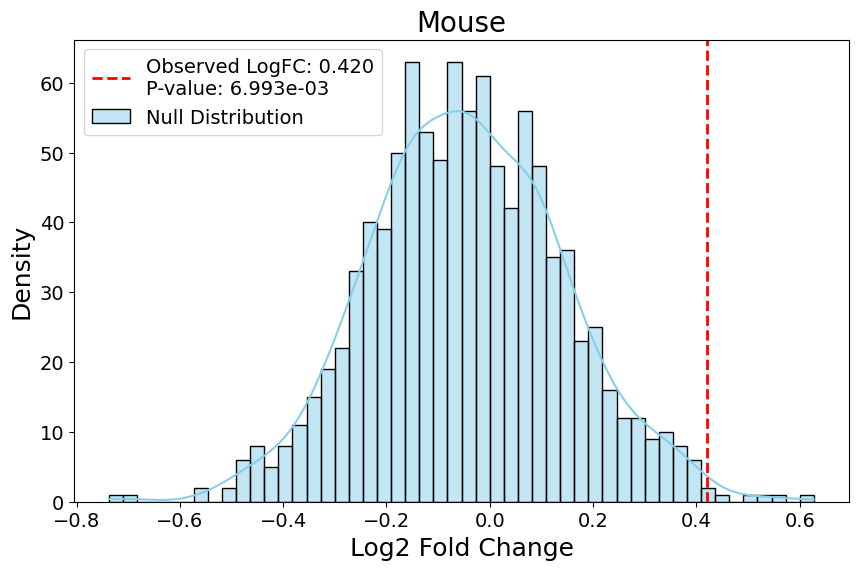

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Increase global font size
plt.rcParams.update({'font.size': 16})

plt.figure(figsize=(10, 6))
sns.histplot(results['null_distribution'], kde=True, color="skyblue",
             label="Null Distribution", bins=50)

plt.axvline(results['observed_logFC'], color="red", linestyle="dashed", linewidth=2,
            label=f"Observed LogFC: {results['observed_logFC']:.3f}\nP-value: {results['p_value']:.3e}")

plt.xlabel("Log2 Fold Change", fontsize=18)
plt.ylabel("Density", fontsize=18)
plt.title("Mouse", fontsize=20)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend(fontsize=14)
plt.show()


# Volacano Plot


In [ ]:
import pandas as pd

#https://docs.google.com/spreadsheets/d/1yV9E3Wkvq5qd0A9OimlJMQ0gMEnKflXgcSQxe1UgYIw/edit?usp=sharing
sheet_id = "1yV9E3Wkvq5qd0A9OimlJMQ0gMEnKflXgcSQxe1UgYIw"
sheet_name = "HiC_metadata"   # change to your sheet name
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&sheet={sheet_name}"

df = pd.read_csv(url)
df.head()


,Dataset,Tissue,Cross,Fold Change,P-value,Unnamed: 5,Notes,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26
0,GSM7305473,large Pre-B cell (CD19+CD43+BP1+),NaN,1.34,0.013,NaN,0.013197,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ENCFF409ZRS,mESC,C57BL6/129s4,1.56,0.001,NaN,0.001200,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ENCFF076GYR,CH12.LX,B10.H-2aH-4bp/Wts,1.24,0.037,NaN,0.037193,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ENCFF909ODS,CH12F3,B10.H-2aH-4bp/Wts,1.29,0.029,NaN,0.029194,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ENCFF584EDJ,mESC,129/Ola,1.44,0.004,NaN,0.004199,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Specific sheet (tab)
import pandas as pd

sheet_id = "1yV9E3Wkvq5qd0A9OimlJMQ0gMEnKflXgcSQxe1UgYIw"

# Access different sheets by changing this value:
sheet_name = "mouse"   # or "Sheet2", "Other_tab", etc.

url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&sheet={sheet_name}"

df = pd.read_csv(url)
print(df.head())


       Dataset                             Tissue              Cross  \
0   GSM7305473  large Pre-B cell (CD19+CD43+BP1+)                NaN   
1  ENCFF409ZRS                               mESC       C57BL6/129s4   
2  ENCFF076GYR                            CH12.LX  B10.H-2aH-4bp/Wts   
3  ENCFF909ODS                             CH12F3  B10.H-2aH-4bp/Wts   
4  ENCFF584EDJ                               mESC            129/Ola   

   Fold Change  P-value Unnamed: 5     Notes Unnamed: 7  Unnamed: 8  \
0         1.34    0.013        NaN  0.013197        NaN         NaN   
1         1.56    0.001        NaN  0.001200        NaN         NaN   
2         1.24    0.037        NaN  0.037193        NaN         NaN   
3         1.29    0.029        NaN  0.029194        NaN         NaN   
4         1.44    0.004        NaN  0.004199        NaN         NaN   

   Unnamed: 9  ...  Unnamed: 17  Unnamed: 18  Unnamed: 19  Unnamed: 20  \
0         NaN  ...          NaN          NaN          NaN         

In [ ]:
# Specific sheet (tab)
import pandas as pd

sheet_id = "1yV9E3Wkvq5qd0A9OimlJMQ0gMEnKflXgcSQxe1UgYIw"

# Access different sheets by changing this value:
sheet_name = "human"   # or "Sheet2", "Other_tab", etc.

url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&sheet={sheet_name}"

df1 = pd.read_csv(url)
print(df1.head())


               Accession                   Tissue  Fold Change  P-value  Notes
0            ENCFF997RGL                   IMR-90         1.57  0.00500    NaN
1  GSE185192_NPC_HiC_MaE                      NPC         1.57  0.01400    NaN
2            ENCFF514XWQ                  GM12878         1.30  0.01300    NaN
3            ENCFF349RZY             keratinocyte         1.47  0.00899    NaN
4            ENCFF543USQ  mammary epithelial cell         1.54  0.00400    NaN


In [ ]:
%config InlineBackend.print_figure_kwargs = {'bbox_inches': 'tight'}

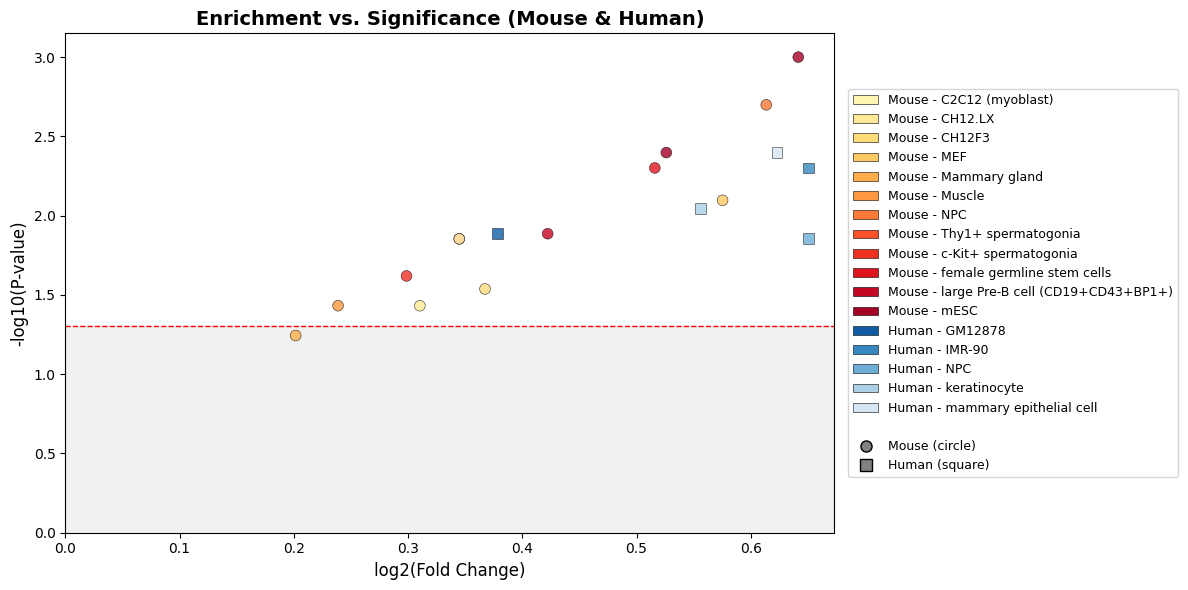

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Transform columns in both dataframes
for d in [df, df1]:
    d["log2FC"] = np.log2(d["Fold Change"])
    d["neglog10P"] = -np.log10(d["P-value"])

# Add a column to identify species
df["Species"] = "Mouse"
df1["Species"] = "Human"

# Combine both
df_combined = pd.concat([df, df1], ignore_index=True)

# Create a combined identifier for coloring
df_combined["Species_Tissue"] = df_combined["Species"] + "_" + df_combined["Tissue"]

# Parameters
p_thresh = 0.05

# Marker styles: Mouse = circle ("o"), Human = square ("s")
markers = {"Mouse": "o", "Human": "s"}

# Define color palettes for each species
mouse_tissues = sorted(df_combined[df_combined["Species"] == "Mouse"]["Tissue"].unique())
human_tissues = sorted(df_combined[df_combined["Species"] == "Human"]["Tissue"].unique())

# Create color maps: yellow to red for mouse, blue to purple for human
mouse_colors = sns.color_palette("YlOrRd", n_colors=len(mouse_tissues))
human_colors = sns.color_palette("Blues_r", n_colors=len(human_tissues))

# Build a color dictionary
color_dict = {}
for i, tissue in enumerate(mouse_tissues):
    color_dict[f"Mouse_{tissue}"] = mouse_colors[i]
for i, tissue in enumerate(human_tissues):
    color_dict[f"Human_{tissue}"] = human_colors[i]

# Adjusted figure size - narrower width
fig, ax = plt.subplots(figsize=(12, 6))

# Shaded area for non-significant region
ax.axhspan(0, -np.log10(p_thresh), color="lightgrey", alpha=0.3)

# Scatter plot with species-specific colors
sns.scatterplot(
    data=df_combined,
    x="log2FC",
    y="neglog10P",
    hue="Species_Tissue",
    style="Species",
    markers=markers,
    palette=color_dict,
    alpha=0.8,
    edgecolor="black",
    linewidth=0.4,
    s=60,
    legend=False,
    ax=ax
)

# Threshold line
ax.axhline(-np.log10(p_thresh), color="red", linestyle="--", linewidth=1)

# Axes settings
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.set_xlabel("log2(Fold Change)", fontsize=12)
ax.set_ylabel("-log10(P-value)", fontsize=12)
ax.set_title("Enrichment vs. Significance (Mouse & Human)", fontsize=14, weight="bold")

# Create custom legend
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# All legend elements in one list
all_handles = []
all_labels = []

# Add tissue/cell line entries
for tissue in mouse_tissues:
    all_handles.append(Patch(facecolor=color_dict[f"Mouse_{tissue}"], edgecolor='black', linewidth=0.4))
    all_labels.append(f"Mouse - {tissue}")

for tissue in human_tissues:
    all_handles.append(Patch(facecolor=color_dict[f"Human_{tissue}"], edgecolor='black', linewidth=0.4))
    all_labels.append(f"Human - {tissue}")

# Add separator
all_handles.append(Patch(facecolor='none', edgecolor='none'))
all_labels.append('')

# Add species markers
all_handles.append(Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=8, markeredgecolor='black', linewidth=0))
all_labels.append('Mouse (circle)')

all_handles.append(Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markersize=8, markeredgecolor='black', linewidth=0))
all_labels.append('Human (square)')

# Create single legend outside the plot
ax.legend(all_handles, all_labels,
          loc='center left',
          bbox_to_anchor=(1.01, 0.5),
          fontsize=9,
          frameon=True)

# Adjust to prevent cutoff
plt.tight_layout()
plt.show()